# Inflation of house pices in Italy

AIM: gather and investigate data that is openly available

In [1]:
import warnings 
from istatapi import discovery, retrieval
import requests
import pandas as pd

warnings.filterwarnings('ignore')
requests.urllib3.disable_warnings()

! pip show istatapi

Name: istatapi
Version: 1.0.0
Summary: Python API for ISTAT (The Italian National Institute of Statistics)
Home-page: https://github.com/Attol8/istatapi
Author: Jacopo Attolini
Author-email: jacopoattolini@gmail.com
License: Apache Software License 2.0
Location: /Users/danieleongari/opt/anaconda3/envs/py312/lib/python3.12/site-packages
Requires: fastcore, matplotlib, pandas, pyopenssl, requests
Required-by: 


In [2]:
all_datasets = discovery.search_dataset("")
display(all_datasets)

,df_id,version,df_description,df_structure_id
0,101_1015,1.3,Crops,DCSP_COLTIVAZIONI
1,101_1030,1.0,"PDO, PGI and TSG quality products",DCSP_DOPIGP
2,101_1033,1.0,slaughtering,DCSP_MACELLAZIONI
3,101_1039,1.2,Agritourism - municipalities,DCSP_AGRITURISMO_COM
4,101_1077,1.0,"PDO, PGI and TSG products: operators - munici...",DCSP_DOPIGP_COM
...,...,...,...,...
504,97_953,1.1,Environmental protection expenditure,DCCN_SPESAPROTAMB
505,98_1066,1.0,Productivity measures - Accounts in the 2014 v...,DCCN_PRODUTTIVITA_B14
506,98_1067,1.0,Productivity measures - Accounts in the 2011 v...,DCCN_PRODUTTIVITA_B11
507,98_197,1.3,Productivity measures,DCCN_PRODUTTIVITA


In [3]:
selected_datasets = (
    all_datasets
    .query('df_description.str.contains("house|constr", case=False)')
    .query('~df_description.str.contains("household", case=False)')
    .sort_values('df_structure_id', ascending=True)
)

count=0
for _, row in selected_datasets.iterrows():
    print(f'{count+1:2d} - v{row["version"]} {row["df_structure_id"]}  - {row["df_description"]}')
    count+=1

 1 - v1.1 DCCV_ABITPROBL  - Damaged, humid and lightless house
 2 - v1.3 DCSC_FABBRESID_1  - Construction costs
 3 - v1.3 DCSC_FIDIMPRCOSTR  - Business confidence in the construction sector
 4 - v1.0 DCSC_INDPREPROCOSTR  - Construction producer prices indeces
 5 - v1.2 DCSC_INDXPRODCOSTR_1  - Index of production in construction
 6 - v1.2 DCSP_IPAB  - House prices (Ipab)


In [4]:
interesting_dss = ["DCSC_FABBRESID_1", "DCSC_FIDIMPRCOSTR",  "DCSC_INDPREPROCOSTR", "DCSC_INDXPRODCOSTR_1", "DCSP_IPAB"] 

for ds_structure_id in interesting_dss:
    print(f"\n############ {ds_structure_id} ################################################################")
    print("Description:", all_datasets.query(f'df_structure_id == "{ds_structure_id}"').iloc[0].df_description)
    print(f"Website: http://dati.istat.it/Index.aspx?DataSetCode={ds_structure_id}")
    try:
        ds = discovery.DataSet(dataflow_identifier=ds_structure_id)
        ds_info = ds.dimensions_info()
        display(ds_info)
        for col in ds_info.dimension:
            print(f" >> {col}")
            display(ds.get_dimension_values(col).sort_values("values_ids").reset_index(drop=True))
            
    except Exception as e:
        print("Error:", e)
        continue


############ DCSC_FABBRESID_1 ################################################################
Description: Construction costs
Website: http://dati.istat.it/Index.aspx?DataSetCode=DCSC_FABBRESID_1


,dimension,dimension_ID,description
0,FREQ,CL_FREQ,Frequency
1,ADJUSTMENT,CL_CORREZ,Adjustment
2,COSTO_GRUPCATEG,CL_COSTO_GRUPCATEG,Group and category of cost
3,ITTER107,CL_ITTER107,Territory
4,TIP_INDI,CL_TIPO_DATO7,Data type 7


 >> FREQ


,values_ids,values_description
0,M,monthly


 >> ADJUSTMENT


...

,values_ids,values_description
0,22,not applicable
1,4,index number
2,6,percentage changes on the previous period
3,7,percentage changes on the same period of the p...
4,8,annual average rate of change


 >> IND_TYPE


,values_ids,values_description
0,18,house price index (base 2010=100) - quarterly ...
1,19,house price index (base 2010=100) - annual ave...
2,20,house price index (base 2010=100) - weights
3,59,house price index (base 2015=100) - quarterly ...
4,60,house price index (base 2015=100) - annual ave...


 >> ABIT_COMPRAV


,values_ids,values_description
0,ALL,H1 - all items
1,EXST_DW,H12 - existing dwellings
2,NEW_DW,H11 - new dwellings


<Axes: xlabel='TIME_PERIOD'>

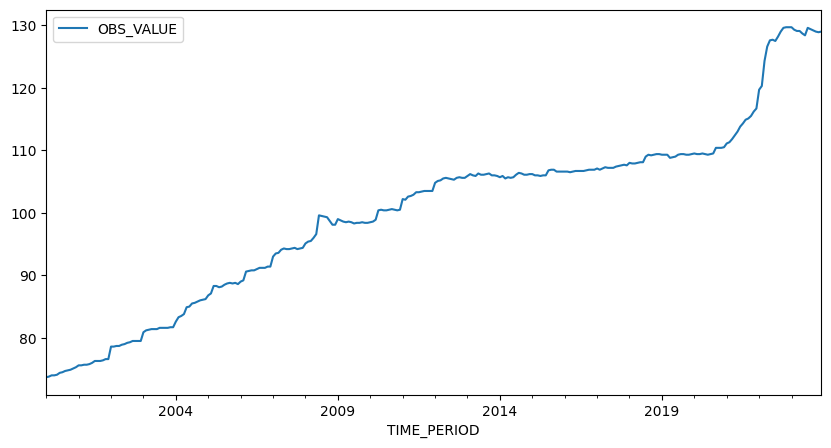

In [5]:
ds = discovery.DataSet(dataflow_identifier="DCSC_FABBRESID_1") 
ds.set_filters(freq="M", adjustment="N", costo_grupcateg="I", itter107="IT", tip_indi=["CONS_CST1","CONS_CST2"])
df1 = retrieval.get_data(ds) 
# fix ["CONS_CST1","CONS_CST2"] overlapping for some years with different baseline
delta12 = df1.query("TIME_PERIOD == '2014-08-01'").OBS_VALUE.values
delta12 = round(delta12[1] - delta12[0], 2)
df1.loc[df1["TIP_INDI"] == "CONS_CST2", "OBS_VALUE"] += delta12
df1 = df1.sort_values(by=["TIP_INDI"]).drop_duplicates(subset=["TIME_PERIOD"], keep="first")
(
    df1
    .sort_values(by=["TIME_PERIOD"])
    .plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

In [6]:
ds = discovery.DataSet(dataflow_identifier="DCSC_FIDIMPRCOSTR") 
#ds.set_filters(freq="M", itter107="IT", tipo_dato='CONS_PRIC', ateco_2007="412000_A", adjustment="N") # 412000_A = construction of residential buildings
df2 = retrieval.get_data(ds) 
(
    df2
    #.sort_values(by=["TIME_PERIOD"])
    #.plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

ValueError: No available data found for the requested query (dataset 111_40)

<Axes: xlabel='TIME_PERIOD'>

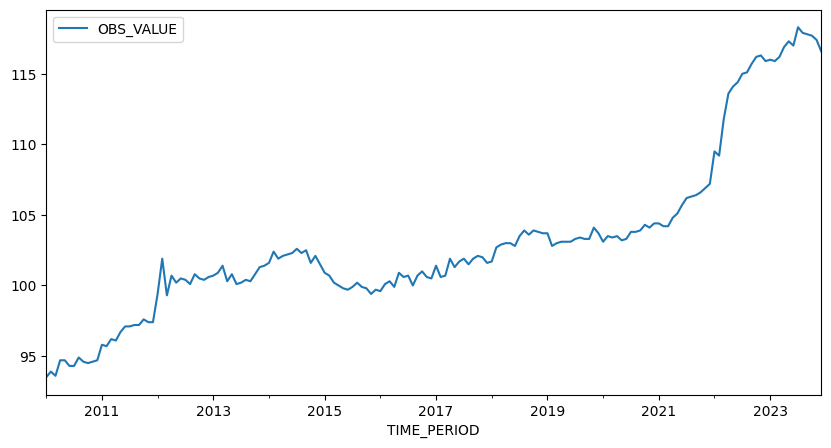

In [ ]:
ds = discovery.DataSet(dataflow_identifier="DCSC_INDPREPROCOSTR") 
ds.set_filters(freq="M", itter107="IT", tipo_dato='CONS_PRIC', ateco_2007="412000_A", adjustment="N") # 412000_A = construction of residential buildings
df3 = retrieval.get_data(ds) 
(
    df3
    .sort_values(by=["TIME_PERIOD"])
    .plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

<Axes: xlabel='TIME_PERIOD'>

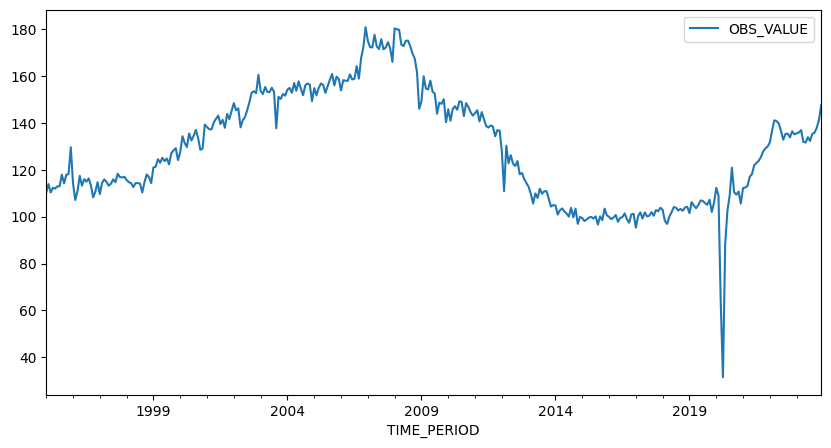

In [ ]:
ds = discovery.DataSet(dataflow_identifier="DCSC_INDXPRODCOSTR_1") 
ds.set_filters(freq="M", ateco_2007="F", adjustment="Y", itter107="IT", tip_indi1=['CONS_PROD2']) # Y - destagionalizzati, CONS_PROD2 contains the most of data
df4 = retrieval.get_data(ds) 
(
    df4
    .sort_values(by=["TIP_INDI1", "TIME_PERIOD"])
    .plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

<Axes: xlabel='TIME_PERIOD'>

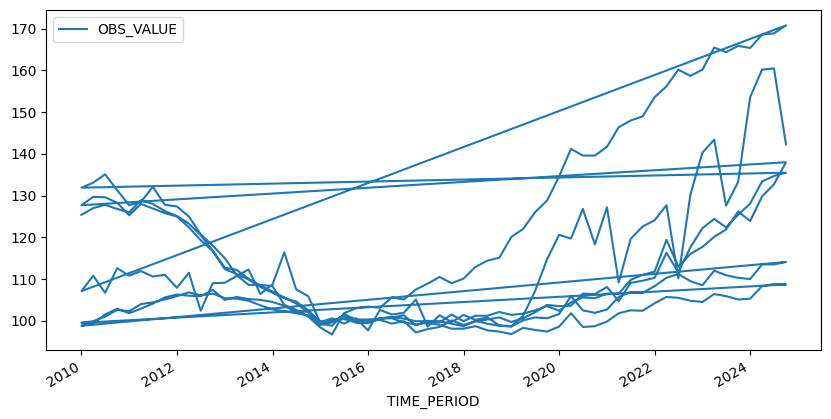

In [ ]:
ds = discovery.DataSet(dataflow_identifier="DCSP_IPAB") 
ds.set_filters(freq="Q", itter107=["IT", "ITC", "ITC45"], misura1="4", ind_type="59", abit_comprav=["EXST_DW", "NEW_DW"]) # ITC45 - Milano
df4 = retrieval.get_data(ds) 
(
    df4
    .sort_values(by=["ITTER107", "ABIT_COMPRAV", "TIME_PERIOD"])
    .plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

In [ ]:
import plotly.express as px
px.line(
    df4, 
    x="TIME_PERIOD",
    y="OBS_VALUE", 
    color="ITTER107", 
    line_dash="ABIT_COMPRAV", 
    title="House Price Index in Italy, Nothern Italy and Milan (2015 = 100)",
).update_layout(width=800).show()

<Axes: xlabel='TIME_PERIOD'>

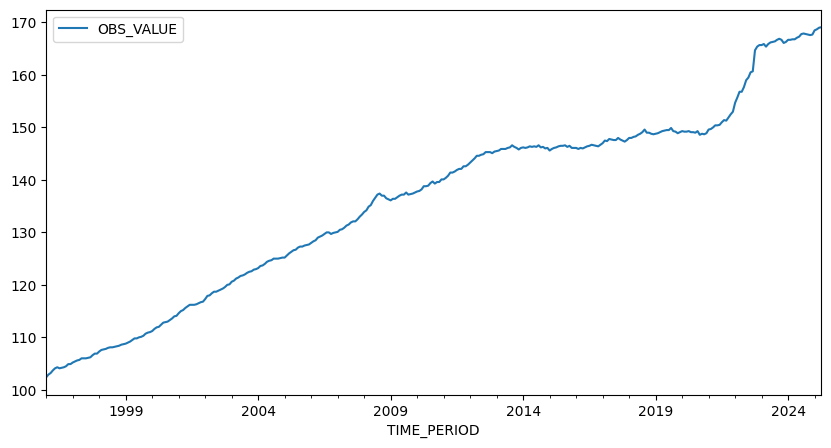

In [ ]:
ds = discovery.DataSet(dataflow_identifier="DCSP_NICUNOB") 
ds.set_filters(freq="M", coicop_nic="00ST", itter107="IT", misura1="4")
df51 = retrieval.get_data(ds) 
ds = discovery.DataSet(dataflow_identifier="DCSP_NICUNOBB2010") 
ds.set_filters(freq="M", coicop_rev_istat="00ST", itter107="IT", misura1="4")
df52 = retrieval.get_data(ds) 
ds = discovery.DataSet(dataflow_identifier="DCSP_NIC1B2015") 
ds.set_filters(freq="M", coicop_rev_istat="00ST", itter107="IT", misura1="4")
df53 = retrieval.get_data(ds) 
delta12 = df51.OBS_VALUE.values[-1] - df52.OBS_VALUE.values[0]
delta23 = df52.OBS_VALUE.values[-1] - df53.OBS_VALUE.values[0]
df5 = pd.concat([
    df51, 
    df52.assign(OBS_VALUE=lambda x: x.OBS_VALUE + delta12), 
    df53.assign(OBS_VALUE=lambda x: x.OBS_VALUE + delta12 + delta23)
]).drop_duplicates(subset=["TIME_PERIOD"]).reset_index(drop=True)
(
    df5
    .sort_values(by=["IND_TYPE", "TIME_PERIOD"])
    .plot(x="TIME_PERIOD", y="OBS_VALUE", figsize=(10,5))
)

In [ ]:
df = (
    df5
    .set_index("TIME_PERIOD")
    [["OBS_VALUE"]]
    .rename(columns={"OBS_VALUE":"NIC Inflation"})
    .join(df1.set_index("TIME_PERIOD")["OBS_VALUE"].rename("Residential Construction Cost"), how="outer")
    .join(df3.set_index("TIME_PERIOD")["OBS_VALUE"].rename("Residential Construction Prices"),how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='IT' and ABIT_COMPRAV=='EXST_DW'")["OBS_VALUE"].rename("House Price Italy Existing"), how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='ITC' and ABIT_COMPRAV=='EXST_DW'")["OBS_VALUE"].rename("House Price North Existing"), how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='ITC45' and ABIT_COMPRAV=='EXST_DW'")["OBS_VALUE"].rename("House Price Milan Existing"), how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='IT' and ABIT_COMPRAV=='NEW_DW'")["OBS_VALUE"].rename("House Price Italy New"), how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='ITC' and ABIT_COMPRAV=='NEW_DW'")["OBS_VALUE"].rename("House Price North New"), how="outer")
    .join(df4.set_index("TIME_PERIOD").query("ITTER107=='ITC45' and ABIT_COMPRAV=='NEW_DW'")["OBS_VALUE"].rename("House Price Milan New"), how="outer")
)
df = df.div(df.loc["2010-01-01"]/100).round(2)
df.to_csv("data/01out_istat_indices.csv", index=True)
px.line(
    df.reset_index(),
    x="TIME_PERIOD",
    y=df.columns,
    log_y=True
).update_traces(connectgaps=True).update_layout(width=1000, height=600).show()
